## k-Nearest Neighbours Classifier

In this part we classify each deposit by a vote of its k nearest deposits in the train folds, in the space of the standardised inputs. The k-NN fits no parameter: it stores the training deposits and assumes that deposits with close inputs have the same label. The deposits, their inputs and their label are those of the naive Bayes notebook (`deposit_data`).

### Main observations

- **Standardisation:** Without it, the distance between deposits is mostly made of the heat treatment temperatures and the current (74% of the total variance of the inputs), and the F1 with 5 neighbours drops from 0.70 to 0.63.
- **k = 1:** The best number of neighbours is 1, with an F1 of 0.80. The validation F1 falls as soon as more neighbours vote (0.70 with 5 neighbours, below the 0.64 of the rule that declares every deposit non-conforming from about 31 neighbours on), unless the votes are weighted by the inverse of the distance. The nearest deposit has the same label in 81% of the cases, the fifth in only 58%: the label changes over short distances, and only the very nearest deposits are informative.
- **Results:** F1 of 0.80 and recall of 0.82, the best recall so far, regression models included (0.81 for the pruned tree of `1B`). The F1 is between that of the random forest (0.76) and of the bagging (0.81) of `1B`.
- **Nested cross-validation:** F1 of 0.75. The best k changes from one fold to the other (1 for three folds, 5 and 33 neighbours with weighted votes for the two others), and the F1 of 0.80 is optimistic by about 0.05.

### Operations in order

1. Load the train set with `load_train` and the labelled deposits with `get_deposit_xy`.
2. Cross-validate the k-NN with 5 neighbours with and without standardisation, and compare the variances of the inputs.
3. Tune the number of neighbours, the weights of the votes and the distance by a grid search on the folds of `helpers/utils.py`, with the F1 on the non-conforming deposits as score, and plot the train and validation F1 against the number of neighbours.
4. Measure how often the 1st to 5th nearest deposits of the train folds have the same label as the deposit.
5. Evaluate the best model with `evaluate_label`, and check its F1 by nested cross-validation.
6. Save it to `results.csv` and compare it with the other models.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, recall_score
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

import sys
sys.path.append("..")  # helpers/ is in modeling/

from helpers.utils import (
    load_train, get_deposit_xy, build_pipeline,
    oof_predict_label, nested_oof_predict_label, evaluate_label, save_results,
)

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)

In [3]:
train = load_train()
X, y, cv = get_deposit_xy(train)

print(X.shape, "| non-conforming:", y.sum())

(175, 32) | non-conforming: 83


In [4]:
scaling = {}
for name, model in [("without scaling", Pipeline([("model", KNeighborsClassifier())])), ("StandardScaler", KNeighborsClassifier())]:
    scores = cross_validate(build_pipeline(model), X, y, cv=cv, scoring=["f1", "recall"])
    scaling[name] = {"validation_F1": scores["test_f1"].mean(), "validation_recall": scores["test_recall"].mean()}
display(pd.DataFrame(scaling).T.round(3))

(100 * X.var() / X.var().sum()).sort_values(ascending=False).head(6).round(2)

,validation_F1,validation_recall
without scaling,0.631,0.601
StandardScaler,0.703,0.720


pwht_temp_C_low     30.92
pwht_temp_C_high    28.15
current_A           14.49
Al_ppm               7.44
O_ppm                6.06
Nb_ppm               5.73
dtype: float64

`build_pipeline` puts a `StandardScaler` before the model, the first row skips it by passing a `Pipeline` without scaler. Both rows use the default k-NN: 5 neighbours and the Euclidean distance.

- **Without scaling:** F1 of 0.63 and recall of 0.60, against 0.70 and 0.72 with the scaler. The distance between deposits is the only ingredient of the k-NN, so it is the model most sensitive to the scale of the inputs.
- **Why:** The mean squared distance between two deposits is twice the sum of the variances of the inputs, so the share of an input in the distance is its share of the total variance (second table, in %). Without scaling, the two heat treatment temperatures (in °C, 31% and 28%) and the current (in A, 14%) make 74% of the distance, and the composition in wt% (C, Mn, Ni...) almost nothing. Once standardised, every non-constant input has the same weight.

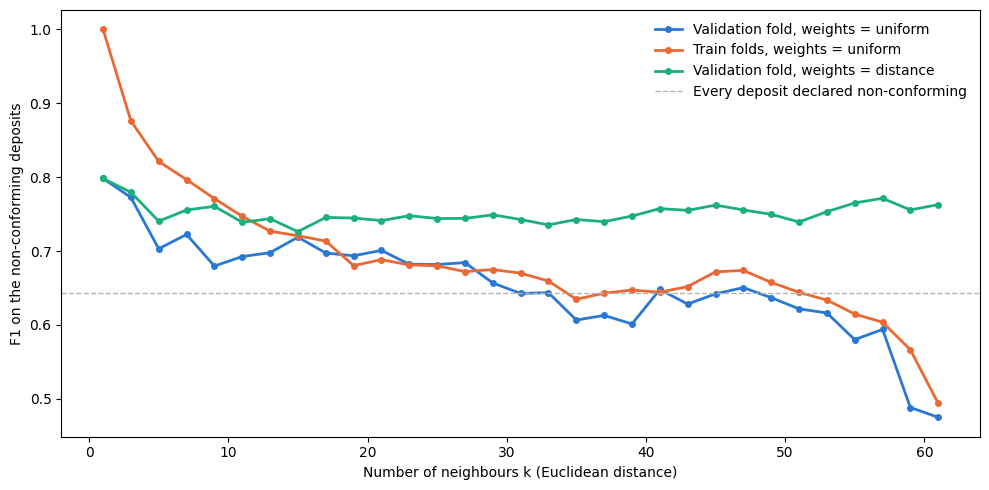

param_model__p,1,2
param_model__weights,,
distance,0.784,0.798
uniform,0.784,0.798


{'model__n_neighbors': 1, 'model__p': 2, 'model__weights': 'uniform'} validation F1: 0.798


In [5]:
search = GridSearchCV(
    build_pipeline(KNeighborsClassifier()),
    {"model__n_neighbors": range(1, 62, 2), "model__weights": ["uniform", "distance"], "model__p": [1, 2]},
    cv=cv,
    scoring="f1",
    return_train_score=True,
    n_jobs=-1,
).fit(X, y)

cv_results = pd.DataFrame(search.cv_results_)
reference = 2 * y.mean() / (1 + y.mean())

fig, ax = plt.subplots(figsize=(10, 5))
for weights, color in [("uniform", "#2a78d6"), ("distance", "#1baf7a")]:
    rows = cv_results[(cv_results["param_model__weights"] == weights) & (cv_results["param_model__p"] == 2)]
    ax.plot(rows["param_model__n_neighbors"], rows["mean_test_score"], color=color, linewidth=2, marker="o", markersize=4, label=f"Validation fold, weights = {weights}")
    if weights == "uniform":
        ax.plot(rows["param_model__n_neighbors"], rows["mean_train_score"], color="#eb6834", linewidth=2, marker="o", markersize=4, label="Train folds, weights = uniform")
ax.axhline(reference, color="#b5b4ae", linewidth=1, linestyle="--", label="Every deposit declared non-conforming")
ax.set_xlabel("Number of neighbours k (Euclidean distance)")
ax.set_ylabel("F1 on the non-conforming deposits")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

display(cv_results.pivot_table(index="param_model__weights", columns="param_model__p", values="mean_test_score", aggfunc="max").round(3))
print(search.best_params_, "validation F1:", round(search.best_score_, 3))

The grid search tries k from 1 to 61 (odd values, so that the two classes cannot tie), the uniform vote and the vote weighted by the inverse of the distance, and the Manhattan (`p = 1`) and Euclidean (`p = 2`) distances. The figure shows the Euclidean distance, the table the best validation F1 of each pair of weights and distance.

- **Train folds:** With k = 1, each training deposit is its own nearest neighbour, so the train F1 is 1, and it falls as k grows. With the weighted vote it stays at 1 for every k (the deposit itself gets an infinite weight), so it is not drawn.
- **Uniform vote:** The validation F1 is the best at k = 1 (0.80), drops to 0.70 at k = 5, and falls below the reference rule from about 31 neighbours on. With 61 neighbours, almost half of the train folds vote, the vote tends toward the majority class (conforming) and the F1 falls to 0.48.
- **Weighted vote:** Between 0.72 and 0.78 for every k above 1, as the nearest neighbours keep most of the weight whatever k.
- **Best:** k = 1 with the Euclidean distance (0.80, the weights do not matter with a single neighbour), the Manhattan distance reaches 0.78.

In [6]:
neighbours = []
for train_idx, val_idx in cv.split():
    pipe = build_pipeline(KNeighborsClassifier()).fit(X.iloc[train_idx], y.iloc[train_idx])
    distance, index = pipe["model"].kneighbors(pipe["scaler"].transform(X.iloc[val_idx]), n_neighbors=5)
    for rank in range(5):
        neighbours.append(pd.DataFrame({
            "rank": rank + 1,
            "distance": distance[:, rank],
            "same_label": y.iloc[val_idx].values == y.iloc[train_idx].iloc[index[:, rank]].values,
        }))
neighbours = pd.concat(neighbours)

display(neighbours.groupby("rank").agg(median_distance=("distance", "median"), same_label=("same_label", "mean")).round(2))

first = neighbours[neighbours["rank"] == 1]
first.groupby(pd.qcut(first["distance"], 4))["same_label"].agg(["size", "mean"]).round(2)

,median_distance,same_label
rank,,
1,0.93,0.81
2,1.29,0.71
3,1.62,0.73
4,1.92,0.65
5,2.11,0.58


,size,mean
distance,,
"(0.027, 0.596]",44,0.93
"(0.596, 0.933]",44,0.86
"(0.933, 1.281]",43,0.63
"(1.281, 61.436]",44,0.80


For each deposit, its 5 nearest deposits in the train folds (standardised inputs, Euclidean distance), with the median distance and the share having the same label as the deposit at each rank. The second table splits the deposits into 4 groups of equal size by the distance to their nearest neighbour.

- **Rank:** The nearest deposit has the same label in 81% of the cases, the second in 71% and the fifth in 58%, while the median distance goes from 0.93 to 2.11. Each added neighbour is farther and less often of the same label, so it adds more noise than information to the vote: hence k = 1.
- **Distance:** When the nearest deposit is very close (distance below 0.6), it has the same label in 93% of the cases. Between 0.93 and 1.28, only 63%: almost all these deposits are MMA deposits (40 of 43), whose label changes with a small change of the inputs.
- **Farthest quarter:** 80% of right labels. It holds the unusual deposits (6 of the 8 CrMo2, the 4 FCA and 7 of the 11 TSA deposits): they are far from every other deposit, but their nearest one is of the same process and has the same label (every TSA and FCA deposit of this quarter).

In [7]:
best = search.best_estimator_

knn = evaluate_label("k-NN classifier", best, train)
display(knn.dropna(axis=1, how="all").round(2))

oof = oof_predict_label(best, train)
pd.DataFrame(confusion_matrix(y, oof["pred_nc"]), index=["conforming", "non-conforming"], columns=["predicted conforming", "predicted non-conforming"])

,model,target,family,n_clf,n_nc,F1_nc,recall_nc,accuracy
0,k-NN classifier,label,all,175,83,0.80,0.82,0.81
1,k-NN classifier,label,C-Mn,161,79,0.81,0.82,0.81
2,k-NN classifier,label,CrMo2,8,1,1.00,1.00,1.00
3,k-NN classifier,label,CrMo91,6,3,0.50,0.67,0.33


,predicted conforming,predicted non-conforming
conforming,73,19
non-conforming,15,68


- **All deposits:** F1 of 0.80 and recall of 0.82: 68 of the 83 non-conforming deposits are caught, for 19 false alarms out of 92 conforming deposits (a precision of 0.78).
- **Per family:** The single non-conforming CrMo2 deposit is caught without false alarm on the 7 others, and 2 of the 3 non-conforming CrMo91 deposits, on 8 and 6 deposits.

In [8]:
nested_pred, nested_params = nested_oof_predict_label(search, train)

print("Nested F1:", round(f1_score(y, nested_pred), 3), "| recall:", round(recall_score(y, nested_pred), 3))
nested_params

Nested F1: 0.749 | recall: 0.771


,n_neighbors,p,weights
fold,,,
0,33,2,distance
1,1,2,uniform
2,1,1,uniform
3,1,2,uniform
4,5,1,distance


The same nested cross-validation as in the naive Bayes notebook: the grid search is redone for each fold on the 4 other folds only.

- **Nested F1:** 0.75 and recall of 0.77, against 0.80 and 0.82. On 4 folds, the uniform vote with k = 1 and the weighted votes are close, so the choice changes: k = 1 for three folds, 5 and 33 neighbours with the weighted vote for the two others. The F1 of 0.80 is optimistic by about 0.05.

In [9]:
results = save_results(knn)

models = ["Baseline (mean)", "Pruned CART", "Bagging", "Random forest", "Extra-Trees", "Naive Bayes classifier", "k-NN classifier"]
label = results[(results["target"] == "label") & results["model"].isin(models)]
label.pivot(index="model", columns="family", values=["F1_nc", "recall_nc", "accuracy"]).reindex(index=models).reindex(columns=["all", "C-Mn", "CrMo2", "CrMo91"], level="family").round(2)

F1_nc                    recall_nc                     \
family                   all  C-Mn CrMo2 CrMo91       all  C-Mn CrMo2 CrMo91   
model                                                                          
Baseline (mean)         0.00  0.00   0.0    0.0      0.00  0.00   0.0   0.00   
Pruned CART             0.77  0.78   1.0    0.0      0.81  0.84   1.0   0.00   
Bagging                 0.81  0.83   0.0    0.5      0.72  0.75   0.0   0.33   
Random forest           0.76  0.77   0.0    0.5      0.64  0.66   0.0   0.33   
Extra-Trees             0.84  0.85   0.0    0.8      0.72  0.73   0.0   0.67   
Naive Bayes classifier  0.70  0.71   0.0    0.5      0.69  0.70   0.0   0.67   
k-NN classifier         0.80  0.81   1.0    0.5      0.82  0.82   1.0   0.67   

                       accuracy                     
family                      all  C-Mn CrMo2 CrMo91  
model                                               
Baseline (mean)            0.53  0.51  0.88   0.50  
Pruned CART                0.77  0.77  1.00   0.33  
Bagging                    0.84  0.84  0.88   0.67  
Random forest              0.81  0.81  0.88   0.67  
Extra-Trees                0.87  0.87  0.88   0.83  
Naive Bayes classifier     0.72  0.73  0.88   0.33  
k-NN classifier            0.81  0.81  1.00   0.33

The k-NN classifier has the best recall of the table (0.82, against 0.81 for the pruned tree of `1B`), and an F1 of 0.80, close to the bagging (0.81) and below the Extra-Trees (0.84). Copying the label of the nearest labelled deposit does about as well as the four regressions and the thresholds, but this result is less stable (nested F1 of 0.75).